In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))
os.chdir("..") 
print("CWD:", os.getcwd()) 

CWD: /Users/oliver/Desktop/BitcoinGraphClassification


In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_curve, auc, 
    classification_report, confusion_matrix
)
from sklearn.model_selection import ParameterGrid

# load data
df = pd.read_csv("data/raw/wallets_features_classes_combined.csv")
df = df[df["class"].isin([1, 2])]

# time splits
train_df = df[df["Time step"] <= 30].copy()
val_df   = df[(df["Time step"] > 30) & (df["Time step"] <= 34)].copy()
test_df  = df[df["Time step"] >= 35].copy()

# feature cols (no address/class/etc.)
drop_cols = ["address", "class", "node_id", "Time step"]
features = [col for col in df.columns if col not in drop_cols]

X_train = train_df[features].to_numpy()
y_train = train_df["class"].map({2: 0, 1: 1}).to_numpy()
X_val   = val_df[features].to_numpy()
y_val   = val_df["class"].map({2: 0, 1: 1}).to_numpy()
X_test  = test_df[features].to_numpy()
y_test  = test_df["class"].map({2: 0, 1: 1}).to_numpy()

# param grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "class_weight": ["balanced"]
}

print("\ngrid search (train=1-30, val=31-34)")
best_score = -1
best_params = None

for params in ParameterGrid(param_grid):
    clf = RandomForestClassifier(random_state=42, **params)
    clf.fit(X_train, y_train)
    y_val_prob = clf.predict_proba(X_val)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, y_val_prob)
    pr_auc = auc(recall, precision)
    if pr_auc > best_score:
        best_score = pr_auc
        best_params = params
    print(f"params: {params} -> pr-auc: {pr_auc:.4f}")

print(f"\nbest params (val pr-auc={best_score:.4f}): {best_params}")

# final train + eval
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)
final_clf = RandomForestClassifier(random_state=42, **best_params)
final_clf.fit(X_trainval, y_trainval)
y_pred = final_clf.predict(X_test)
y_prob = final_clf.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("\ntest split (time step 35+)")
print("test results:")
print(f"accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"f1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"pr-auc: {pr_auc:.4f}")
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nclassification report:")
print(classification_report(y_test, y_pred, digits=4))




grid search (train=1-30, val=31-34)
params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100} -> pr-auc: 0.6451
params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} -> pr-auc: 0.6889
params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100} -> pr-auc: 0.6237
params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200} -> pr-auc: 0.6554
params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100} -> pr-auc: 0.6584
params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200} -> pr-auc: 0.6466
params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100} -> pr-auc: 0.6360
params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200} -> pr-auc: 0.6456
params: {'class_weight': 'b

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"pr-auc = {pr_auc:.2f}")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("precision-recall curve (random forest)")
plt.legend()
plt.grid(True)
plt.savefig("rf_precision_recall_curve.pdf")  
plt.close()


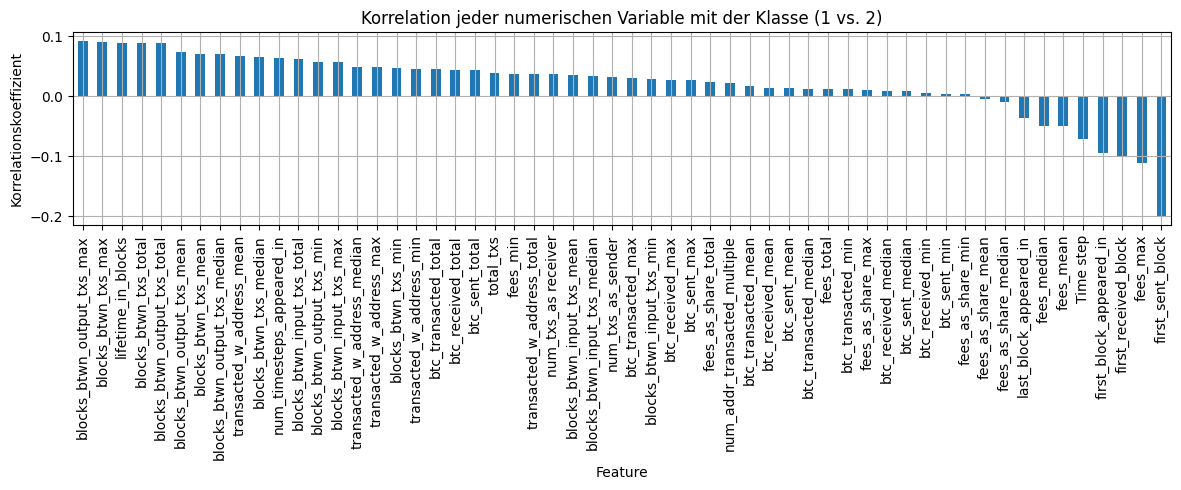

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


df_full = pd.read_csv("data/raw/wallets_features_classes_combined.csv")


df_filtered = df_full[df_full["class"].isin([1, 2])]


numeric_df = df_filtered.select_dtypes(include=[np.number])


correlations = numeric_df.corr(numeric_only=True)["class"].drop("class")

plt.figure(figsize=(12, 5))
correlations.sort_values(ascending=False).plot(kind="bar")
plt.title("correlation of features with class")
plt.xlabel("Feature")
plt.ylabel("Correlation Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
correlations = pd.DataFrame(data.x.numpy()).corrwith(pd.Series(data.y.numpy()))
correlations.abs().sort_values(ascending=False).head(10)


8     0.128944
53    0.086455
9     0.083741
2     0.078349
51    0.075123
40    0.070380
6     0.067528
54    0.062273
15    0.061449
52    0.060689
dtype: float64

In [7]:
print("Train enthält -1:", (data.y[train_idx] == -1).sum())
print("Test enthält -1:", (data.y[test_idx] == -1).sum())



Train enthält -1: tensor(0)
Test enthält -1: tensor(0)


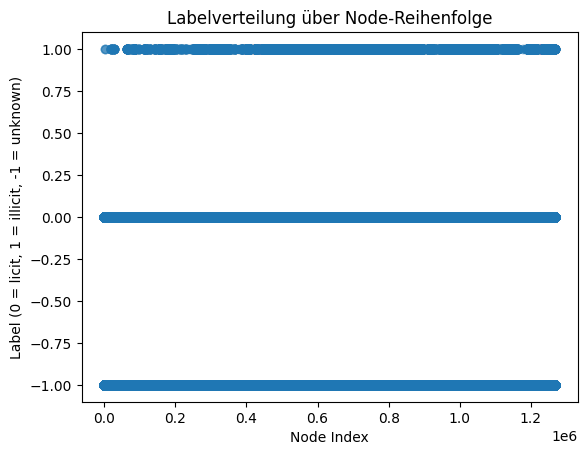

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(range(len(data.y)), data.y.numpy(), alpha=0.3)
plt.title("label distribution over node order") 
plt.xlabel("Node Index")
plt.ylabel("Label (0 = licit, 1 = illicit, -1 = unknown)")
plt.show()
